# Prediciendo la diabetes

## Resumen

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir a partir de medidas diagnósticas, si un paciente tiene o no diabetes.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("./apple.mplstyle")
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib


SEPARATOR = 120 * "-"

## 1. Exploración del dataset (EDA)

### 1.1. Carga y estructura

In [3]:
df = pd.read_csv("../data/raw/diabetes.csv")

print(f"Nulos:\n\n{df.isnull().sum()}")
print(SEPARATOR)

print(f"Duplicados encontrados: {df.duplicated().sum()}\n")
if df.duplicated().sum() != 0:
    print(f"Filas duplicadas:\n\n{df[df.duplicated()]}")
print(SEPARATOR)

print("df.info:\n")
df.info()
print(SEPARATOR)

print(f"Shape:\n\n{df.shape}")
print(SEPARATOR)

print(f"df.head():\n{df.head()}")

Nulos:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
------------------------------------------------------------------------------------------------------------------------
Duplicados encontrados: 0

------------------------------------------------------------------------------------------------------------------------
df.info:

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   In

### 1.2. Distribución de Outcome

In [4]:
outcome_distribution = pd.DataFrame({
    "Cantidad": df["Outcome"].value_counts(),
    "Porcentaje": df["Outcome"].value_counts(normalize=True) * 100
})

print(outcome_distribution)

         Cantidad  Porcentaje
Outcome                      
0             500   65.104167
1             268   34.895833


### 1.3. Estadísticas descriptivas

In [5]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [6]:
zero_suspicious_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_suspicious_summary = pd.DataFrame({
    "Ceros": (df[zero_suspicious_columns] == 0).sum(),
    "Porcentaje" : ((df[zero_suspicious_columns] == 0).sum() / len(df)) * 100
})

print(zero_suspicious_summary.sort_values(by="Ceros", ascending=False))

               Ceros  Porcentaje
Insulin          374   48.697917
SkinThickness    227   29.557292
BloodPressure     35    4.557292
BMI               11    1.432292
Glucose            5    0.651042


- `Insulin`: Muchísimos pacientes sin medición de insulina. Casi la mitad del dataset. No conviene usar sin tratarla antes.
- `SkinThickness`: Hay mucha gente que no tiene registro. Quiero revisar si estos registros coinciden con otros ceros sospechosos, porque podrían formar parte del mismo problema de falta de medición.
- `BloodPressure`: Algunos ceros. Un 4% del dataset, habrá que tratarlos.
- `BMI`: Hay pocos registros con valor 0. Aquí podría tener sentido imputarlos más adelante con una mediana.
- `Glucose`: Una glucosa de 0 no tiene sentido en este contexto. Como son pocos casos prefiero esperar a ver el patrón completo antes de tocarla.

Voy a revisar cuántos registros tienen uno o varios ceros sospechosos en común para decidir si conviene eliminar filas, imputar valores o descartar alguna variable.

In [7]:
zero_mask = df[zero_suspicious_columns] == 0

zeros_per_row = zero_mask.sum(axis=1)

zeros_per_row.value_counts().sort_index()

zeros_per_row_summary = pd.DataFrame({
    "Cantidad de filas": zeros_per_row.value_counts().sort_index(),
    "Porcentaje": zeros_per_row.value_counts(normalize=True).sort_index() * 100
})

print(zeros_per_row_summary)

   Cantidad de filas  Porcentaje
0                392   51.041667
1                142   18.489583
2                199   25.911458
3                 28    3.645833
4                  7    0.911458


Viendo esta tabla, hay 35 registros con demasiados ceros sospechosos: 28 filas con 3 ceros y 7 filas con 4 ceros. No son nulos reales para pandas, pero sí parecen mediciones faltantes.

Prefiero eliminar esas filas antes de imputar, porque rellenar tantas variables en un mismo registro sería inventar demasiada información. Para las filas con 1 o 2 ceros sospechosos, voy a imputar más adelante después del split.

### 1.4. Correlaciones

#### Correlaciones (heatmap)

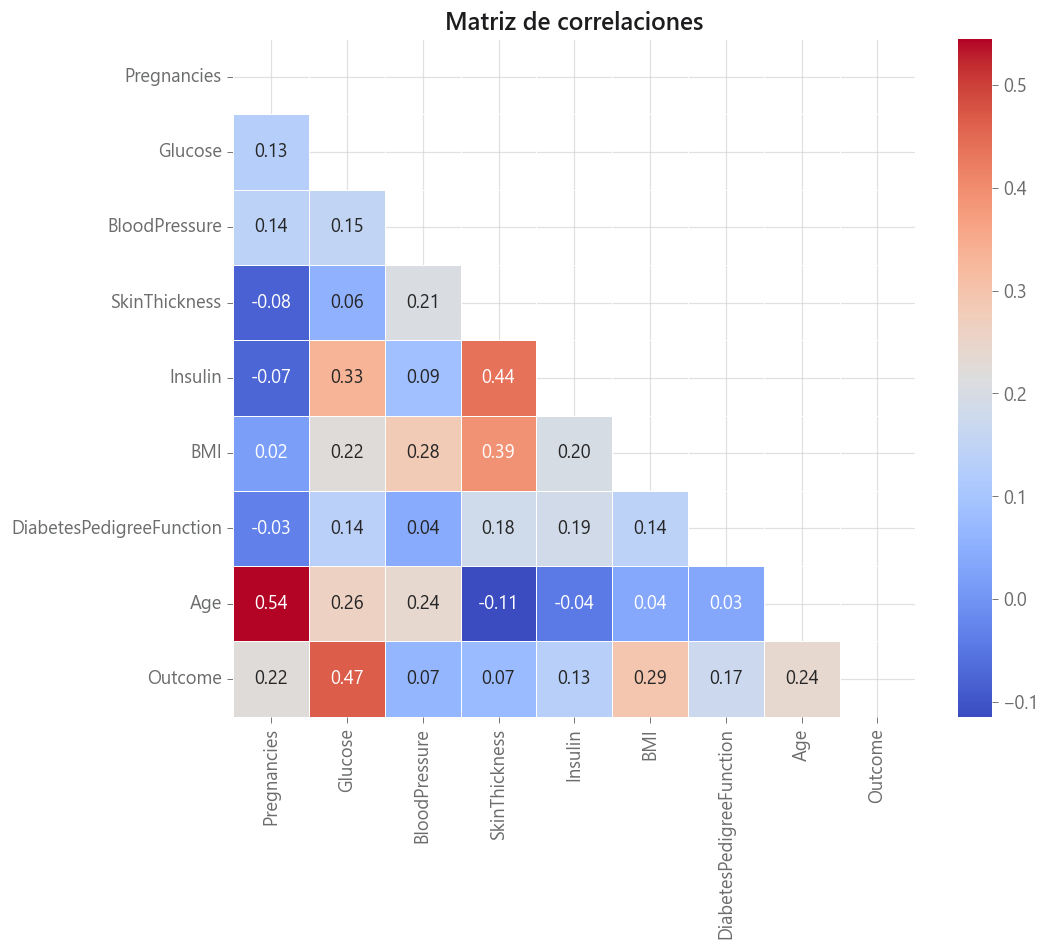

In [8]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlaciones")
plt.show()

**Observaciones del heatmap:**

- `Glucose` tiene la correlación más alta con `Outcome` (0.47). Esto me parece lógico porque la glucosa es justamente lo que se mide para diagnosticar diabetes.
- `BMI` también correlaciona moderadamente con `Outcome`. Tiene sentido porque el sobrepeso está relacionado con el riesgo de diabetes.
- `Age` tiene correlación positiva con `Outcome` también, aunque no es tan fuerte como la glucosa.
- No veo dos variables predictoras que estén tan correlacionadas entre sí como para preocuparme por multicolinealidad. Por ejemplo `Glucose` e `Insulin` solo correlacionan en 0.33. No es demasiado alto.

### 1.5. Outliers (exploración visual)
**Nota**: Los árboles de decisión suelen aguantar mejor los outliers que otros modelos, porque separan los datos con umbrales. Aun así los reviso para entender el dataset, pero no los voy a tratar a no ser que parezcan errores claros.

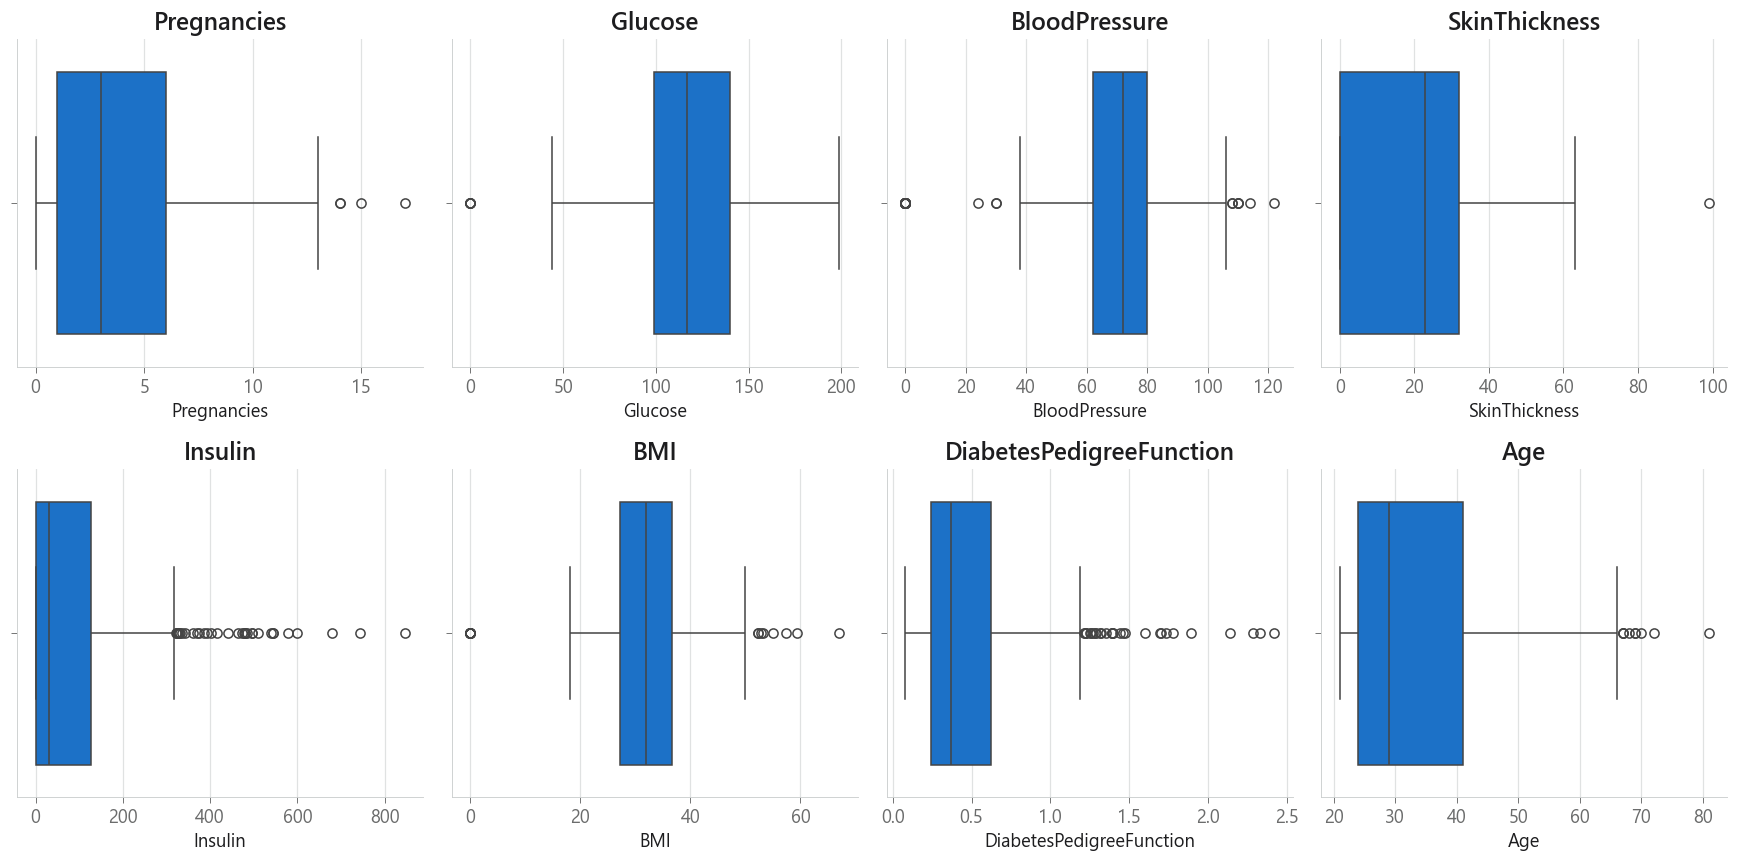

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(df.columns[:-1]):
    sns.boxplot(x=df[col], ax=axes[idx])
    axes[idx].set_title(col)

plt.tight_layout()
plt.show()

**Observaciones de outliers:**

- `Pregnancies` tiene varios valores altos. No los voy a tratar como errores porque pueden ser casos reales y además pueden estar relacionados con antecedentes de embarazo o diabetes gestacional.
- `Insulin` aparece muy dispersa y con valores extremos. De momento solo lo dejo anotado, porque esta variable ya venía mostrando un comportamiento raro por la cantidad de valores en 0.
- `SkinThickness` también muestra un boxplot extraño, aunque aquí el problema principal no parecen ser solo los outliers, sino la cantidad de registros con valor 0.
- `DiabetesPedigreeFunction` tiene una cola larga hacia la derecha. Hay pocos pacientes con valores muy altos, pero no parece motivo suficiente para eliminar registros.

No voy a eliminar outliers solo por estar lejos del resto. En este modelo no pesan como en una regresión. El árbol trabaja con cortes del tipo `Glucose <= x`. Si son valores posibles, prefiero dejarlos porque pueden representar pacientes reales.

## 2. Preprocesamiento

### 2.1. Limpieza de ceros sospechosos

In [10]:
zero_suspicious_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_mask = df[zero_suspicious_columns] == 0
zeros_per_row = zero_mask.sum(axis=1)

df_clean = df[zeros_per_row < 3].copy().reset_index(drop=True)

df_clean = df_clean.drop(columns=["Insulin"])

print(f"Shape original: {df.shape}")
print(f"Shape después de eliminar filas con 3+ ceros y quitar Insulin: {df_clean.shape}")
print(SEPARATOR)

print(f"Filas eliminadas: {df.shape[0] - df_clean.shape[0]}")
print(SEPARATOR)

print(f"Columnas restantes:\n\n{df_clean.columns.tolist()}")

Shape original: (768, 9)
Shape después de eliminar filas con 3+ ceros y quitar Insulin: (733, 8)
------------------------------------------------------------------------------------------------------------------------
Filas eliminadas: 35
------------------------------------------------------------------------------------------------------------------------
Columnas restantes:

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


En esta parte elimino los registros con 3 o más ceros sospechosos, porque faltan demasiadas mediciones como para imputarlos con confianza.

También elimino `Insulin`, porque casi la mitad de sus valores son 0. Si había pensado en imputar pero sería reconstruir demasiados datos. Prefiero perder esa columna antes que meter información inventada en el modelo.

### 2.2. Train/Test Split

In [11]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (586, 7)
X_test: (147, 7)
y_train: (586,)
y_test: (147,)


Divido el dataset antes de imputar valores para evitar data leakage. La idea es que cualquier estadística usada para rellenar datos se calcule solo con train, no con todo el dataset. Además uso `stratify=y` para mantener una proporción parecida de pacientes con y sin diabetes en train y test.

### 2.3. Imputación post-split

In [12]:
columns_to_impute = ["Glucose", "BloodPressure", "SkinThickness", "BMI"]

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

X_train_imputed[columns_to_impute] = X_train_imputed[columns_to_impute].replace(0, np.nan)
X_test_imputed[columns_to_impute] = X_test_imputed[columns_to_impute].replace(0, np.nan)

train_medians = X_train_imputed[columns_to_impute].median()

X_train_imputed[columns_to_impute] = X_train_imputed[columns_to_impute].fillna(train_medians)
X_test_imputed[columns_to_impute] = X_test_imputed[columns_to_impute].fillna(train_medians)

print("Ceros sospechosos en train después de imputar:")
print((X_train_imputed[columns_to_impute] == 0).sum())
print(SEPARATOR)

print("Ceros sospechosos en test después de imputar:")
print((X_test_imputed[columns_to_impute] == 0).sum())

Ceros sospechosos en train después de imputar:
Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
dtype: int64
------------------------------------------------------------------------------------------------------------------------
Ceros sospechosos en test después de imputar:
Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
dtype: int64


In [13]:
X_train_A = X_train_imputed.copy()
X_test_A = X_test_imputed.copy()

X_train_B = X_train_imputed.drop(columns=["SkinThickness"])
X_test_B = X_test_imputed.drop(columns=["SkinThickness"])

print(f"Dataset A con SkinThickness: {X_train_A.shape}, {X_test_A.shape}")
print(f"Dataset B sin SkinThickness: {X_train_B.shape}, {X_test_B.shape}")

Dataset A con SkinThickness: (586, 7), (147, 7)
Dataset B sin SkinThickness: (586, 6), (147, 6)


Imputo los ceros sospechosos después del split. Calculo las medianas solo con `X_train` y luego aplico esos valores a train y test.

También creo dos versiones del dataset porque dudo de `SkinThickness`. Tiene muchos ceros, pero puede seguir aportando información. Pruebo una versión con esa columna y otra sin ella.

## 3. Modelado

### 3.1. Modelo base

Dataset A (con `SkinThickness`)

In [14]:
model_A = DecisionTreeClassifier(random_state=42)
model_A.fit(X_train_A, y_train)

y_pred_A = model_A.predict(X_test_A)

print("Resultados dataset A (con SkinThickness):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_A):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_A):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_A):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_A):.4f}")
print(SEPARATOR)
print(classification_report(y_test, y_pred_A))

Resultados dataset A (con SkinThickness):
Accuracy: 0.7755
Precision: 0.7143
Recall: 0.5882
F1-score: 0.6452
------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        96
           1       0.71      0.59      0.65        51

    accuracy                           0.78       147
   macro avg       0.76      0.73      0.74       147
weighted avg       0.77      0.78      0.77       147



Dataset B (sin `SkinThickness`)

In [15]:
model_B = DecisionTreeClassifier(random_state=42)
model_B.fit(X_train_B, y_train)

y_pred_B = model_B.predict(X_test_B)

print("Resultados dataset B (sin SkinThickness):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_B):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_B):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_B):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_B):.4f}")
print(SEPARATOR)
print(classification_report(y_test, y_pred_B))

Resultados dataset B (sin SkinThickness):
Accuracy: 0.6803
Precision: 0.5417
Recall: 0.5098
F1-score: 0.5253
------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.77      0.76        96
           1       0.54      0.51      0.53        51

    accuracy                           0.68       147
   macro avg       0.64      0.64      0.64       147
weighted avg       0.68      0.68      0.68       147



Comparación de `dataset A` y `dataset B`

In [16]:
base_results = pd.DataFrame({
    "Dataset": ["A (con SkinThickness)", "B (sin SkinThickness)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_A),
        accuracy_score(y_test, y_pred_B)
    ],
    "Precision": [
        precision_score(y_test, y_pred_A),
        precision_score(y_test, y_pred_B)
    ],
    "Recall": [
        recall_score(y_test, y_pred_A),
        recall_score(y_test, y_pred_B)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_A),
        f1_score(y_test, y_pred_B)
    ]
})

print(base_results)

                 Dataset  Accuracy  Precision    Recall  F1-score
0  A (con SkinThickness)  0.775510   0.714286  0.588235  0.645161
1  B (sin SkinThickness)  0.680272   0.541667  0.509804  0.525253


#### Interpretación de métricas

El `dataset A`, conservando `SkinThickness`, gana en todas las métricas al `dataset B`.

Esto me confirma que no convenía eliminar esa columna solo porque tiene muchos ceros. Después de imputarla parece dar información útil al árbol, así que sigo con el `dataset A`.

### 3.2. Comparación de criterios de pureza

El proyecto pide probar diferentes funciones de pureza. En clase hemos visto que estos parámetros son los que hacen que el árbol decida qué división deja los nodos más puros. Comparo `gini`, `entropy` y `log_loss` cambiando solo ese criterio para ver cuál funciona mejor en este dataset.

In [17]:
criteria = ["gini", "entropy", "log_loss"]

criterion_results = []

for criterion in criteria:
    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )
    
    model.fit(X_train_A, y_train)
    y_pred = model.predict(X_test_A)
    
    criterion_results.append({
        "Criterion": criterion,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

criterion_results_df = pd.DataFrame(criterion_results)

print(criterion_results_df)

  Criterion  Accuracy  Precision    Recall  F1-score
0      gini  0.775510   0.714286  0.588235  0.645161
1   entropy  0.693878   0.568182  0.490196  0.526316
2  log_loss  0.693878   0.568182  0.490196  0.526316


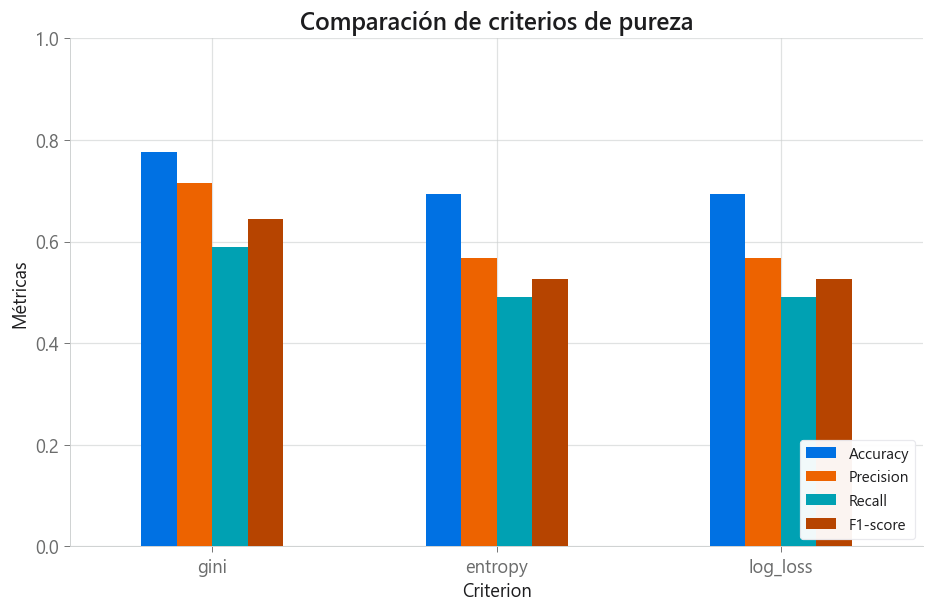

In [26]:
criterion_results_df.set_index("Criterion").plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de criterios de pureza")
plt.ylabel("Métricas")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Al comparar los tres criterios de pureza, `gini` obtiene mejores resultados en todas las métricas. Tanto `entropy` como `log_loss` devuelven exactamente los mismos valores y quedan por debajo.

Así que sigo optimizando con `criterion="gini"`.

### 3.3. Optimización con GridSearchCV

Primero pruebo `GridSearchCV` usando `f1` como métrica, porque busca un equilibrio entre precision y recall.

Como el problema está relacionado con salud, también hago otra prueba priorizando `recall`, para ver si el modelo consigue detectar más positivos reales.

#### GridSearchCV priorizando F1-score

In [19]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini"]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_A, y_train)

print(f"Mejores hiperparámetros:\n{grid_search.best_params_}")
print(SEPARATOR)
print(f"Mejor F1-score en validación cruzada: {grid_search.best_score_:.4f}")

Mejores hiperparámetros:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}
------------------------------------------------------------------------------------------------------------------------
Mejor F1-score en validación cruzada: 0.6717


#### GridSearchCV priorizando recall

Como el problema está relacionado con salud, también pruebo a optimizar usando `recall`. La idea es ver si el modelo puede detectar más positivos reales, aunque eso pueda aumentar los falsos positivos.

In [20]:
grid_search_recall = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search_recall.fit(X_train_A, y_train)

print(f"Mejores hiperparámetros priorizando recall:\n{grid_search_recall.best_params_}")
print(SEPARATOR)
print(f"Mejor recall en validación cruzada: {grid_search_recall.best_score_:.4f}")

Mejores hiperparámetros priorizando recall:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}
------------------------------------------------------------------------------------------------------------------------
Mejor recall en validación cruzada: 0.7213


Los dos GridSearch llegan a los mismos hiperparámetros: `max_depth=4`, `min_samples_leaf=10` y `min_samples_split=2`.

Esto me deja más tranquilo porque aunque cambie la métrica de optimización de `f1` a `recall`, el mejor árbol encontrado es el mismo.

### 3.4. Evaluación final

#### Métricas en test

In [21]:
best_model = grid_search.best_estimator_
best_model_recall = grid_search_recall.best_estimator_

y_pred_best = best_model.predict(X_test_A)
y_pred_recall = best_model_recall.predict(X_test_A)

print("Resultados del modelo final optimizado:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_best):.4f}")
print(SEPARATOR)
print(classification_report(y_test, y_pred_best))

Resultados del modelo final optimizado:
Accuracy: 0.7007
Precision: 0.5593
Recall: 0.6471
F1-score: 0.6000
------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.73      0.76        96
           1       0.56      0.65      0.60        51

    accuracy                           0.70       147
   macro avg       0.68      0.69      0.68       147
weighted avg       0.71      0.70      0.71       147



Los modelos optimizados con `f1` y con `recall` dan exactamente los mismos resultados en test. Esto pasa porque ambos GridSearch han elegido los mismos hiperparámetros.

Lo malo frente al modelo base es que baja el accuracy, la precision y el F1-score. El modelo optimizado marca más falsos positivos, aunque deja escapar menos positivos reales.

En este caso sigo con el modelo optimizado porque mejora el recall de la clase positiva. Como el problema está relacionado con salud, prefiero reducir falsos negativos: es peor no detectar un posible caso de diabetes que marcar un falso positivo que luego pueda revisarse con pruebas médicas.

Este modelo no lo entiendo como un diagnóstico médico. Lo veo más como una herramienta de cribado inicial que luego tendría que revisar un profesional.

#### Matriz de confusión

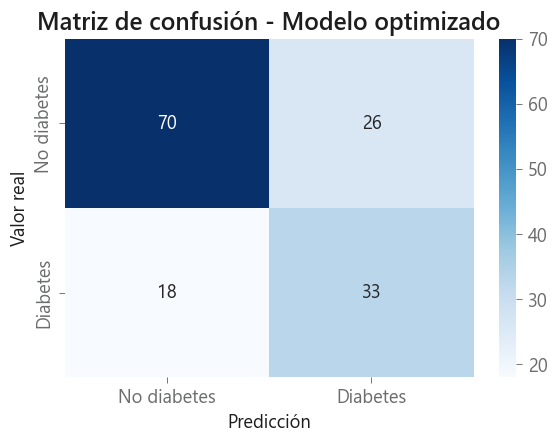

In [22]:
conf_matrix = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Modelo optimizado")
plt.show()

#### Tabla comparativa

In [23]:
final_comparison = pd.DataFrame({
    "Modelo": ["Base", "Optimizado F1", "Optimizado recall"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_A),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_recall)
    ],
    "Precision": [
        precision_score(y_test, y_pred_A),
        precision_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_recall)
    ],
    "Recall": [
        recall_score(y_test, y_pred_A),
        recall_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_recall)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_A),
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_recall)
    ]
})

print(final_comparison)

              Modelo  Accuracy  Precision    Recall  F1-score
0               Base   0.77551   0.714286  0.588235  0.645161
1      Optimizado F1   0.70068   0.559322  0.647059  0.600000
2  Optimizado recall   0.70068   0.559322  0.647059  0.600000


#### Visualización comparativa

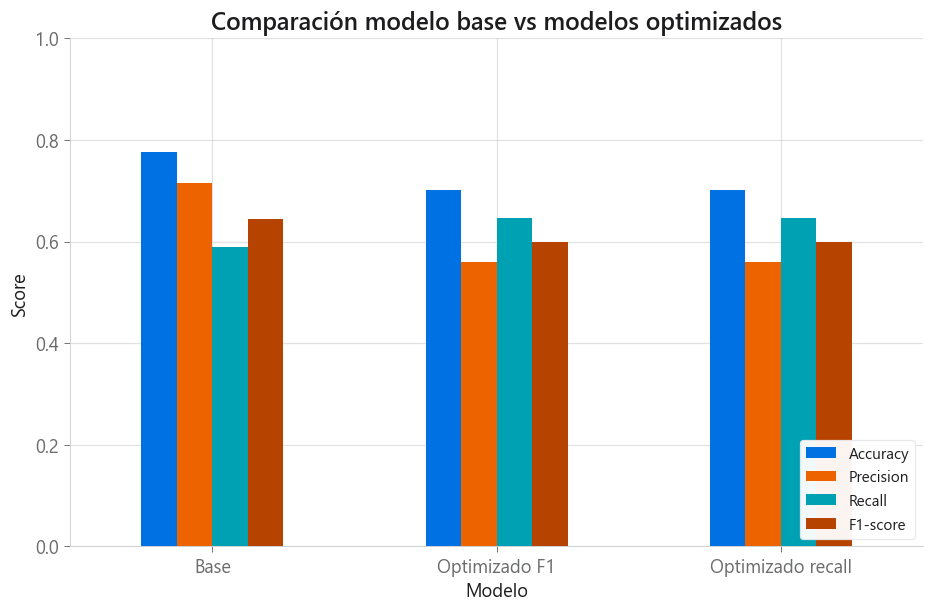

In [24]:
final_comparison.set_index("Modelo").plot(kind="bar", figsize=(10, 6))

plt.title("Comparación modelo base vs modelos optimizados")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

El modelo base queda mejor en accuracy, precision y F1-score. El optimizado no mejora el modelo en general, pero sí sube el recall de la clase positiva de 0.5882 a 0.6471.

No es una mejora enorme, pero en este caso me interesa porque significa que el modelo deja escapar menos positivos reales. Lo malo es que para conseguir eso marca más falsos positivos.

Por eso lo veo como un tradeoff. Pierdo rendimiento general, pero gano algo de sensibilidad en la clase que más me importa detectar.

## 4. Guardado del modelo

In [25]:
joblib.dump(best_model, "../models/decision_tree_diabetes.pkl")

print("Modelo guardado en ../models/decision_tree_diabetes.pkl")

Modelo guardado en ../models/decision_tree_diabetes.pkl


Guardo el modelo optimizado porque es el que he elegido como modelo final. En este caso da igual guardar el optimizado con `f1` o el optimizado con `recall` porque los dos GridSearch han llegado al mismo árbol.

No es el que mejor queda en todas las métricas pero mejora el recall de la clase positiva.

## 5. Conclusiones

En este proyecto he trabajado con un dataset médico para predecir si un paciente tiene o no diabetes a partir de distintas medidas diagnósticas.

Durante el EDA he visto que no había nulos ni duplicados, pero sí algunos ceros en columnas que no tienen sentido, como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`. Por eso he eliminado las filas con muchas mediciones faltantes, he descartado `Insulin` por tener prácticamente la mitad de valores en 0 y he imputado el resto de ceros después del split para evitar data leakage.

He probado dos versiones del dataset: una conservando `SkinThickness` y otra eliminándola. La versión con `SkinThickness` ha obtenido mejores resultados.

También he comparado los criterios de pureza `gini`, `entropy` y `log_loss`. El criterio `gini` ha sido el que mejor ha funcionado.

Al final he optimizado el modelo con `GridSearchCV` usando dos métricas. Primero `f1-score` y después `recall`. Los dos GridSearch han llegado al mismo árbol. Aunque el modelo base tiene mejores métricas generales, el modelo optimizado mejora ligeramente el recall de la clase positiva. Por eso no lo interpreto como una mejora global, sino como un tradeoff: pierdo rendimiento general, pero gano algo de sensibilidad en la clase que más me interesa detectar. En un problema relacionado con salud prefiero reducir falsos negativos, ya que es peor no detectar un posible caso de diabetes que marcar un falso positivo que luego se pueda revisar con pruebas médicas.

No entiendo este modelo como un diagnóstico médico, sino como una herramienta de cribado inicial que luego debe revisar un profesional.

Para algunas decisiones me he apoyado en documentación externa:

- Documentación de scikit-learn sobre árboles de decisión: pureza, interpretabilidad del modelo y riesgo de overfitting.
- Documentación de scikit-learn sobre "Common pitfalls": para saber en qué momento imputar y evitar data leakage.
- Artículo "Decision tree methods: applications for classification and prediction" de Song y Lu (2015): árboles de decisión en problemas de clasificación e investigación médica.
- Recurso de NCBI Bookshelf sobre sensibilidad y especificidad: por qué en un problema de salud tiene sentido priorizar el recall de la clase positiva.